In [63]:
from nvmesnoop import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn import cluster

In [64]:
trace_datas = pd.read_csv('nvme-0828-0908.csv')

## lba 분포의 historygram 

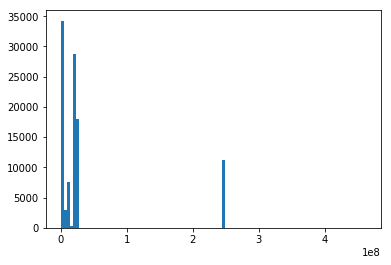

In [65]:
plt.hist(trace_datas['slba'], bins=100)
plt.show()

## 앞 부분 백만 operation의 lba 분포

In [66]:
datas = trace_datas[['slba', 'len']].set_index(trace_datas['timestamp']).head(n=1000000)

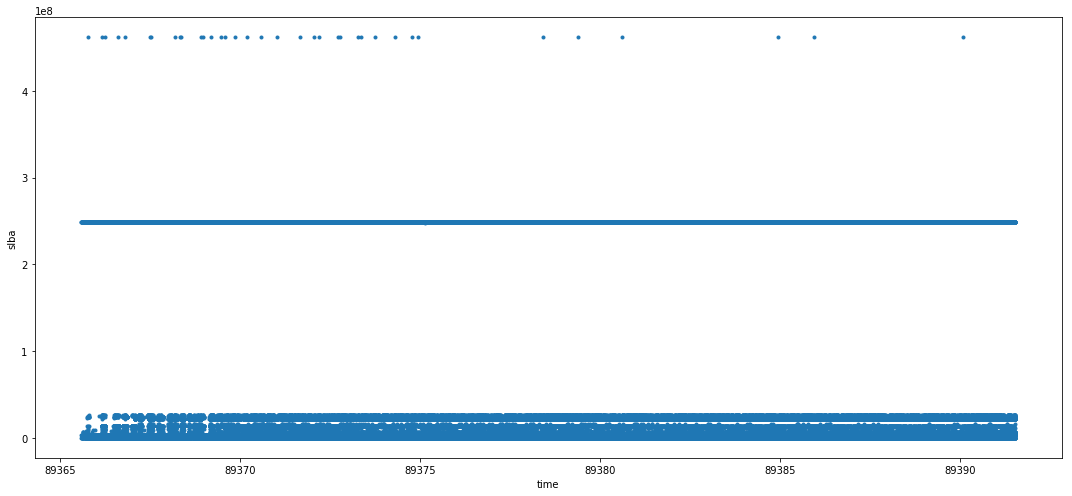

In [67]:
fig = plt.figure(figsize=(15, 7))
plt.plot(datas['slba'], '.')
plt.ylabel('slba')
plt.xlabel('time')
fig.tight_layout()
plt.show()

## KMeans clustring 적용

In [68]:
k = 4
kmeans = cluster.KMeans(n_clusters=k)
kmeans.fit(datas)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

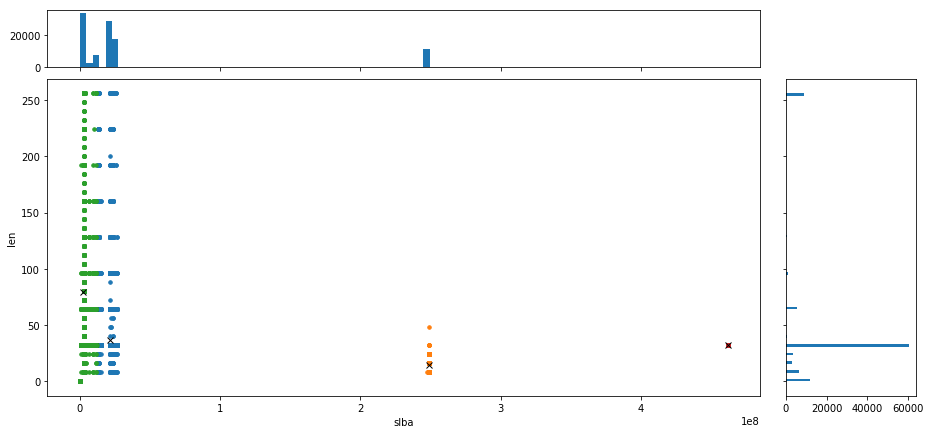

In [84]:
# from matplotlib.ticker import NullFormatter
nullfmt = NullFormatter()         # no labels

# definitions for the axes
left, width = 0.1, 0.55
bottom, height = 0.1, 0.55
bottom_h = left_h = left + width + 0.02

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom_h, width, 0.1]
rect_histy = [left_h, bottom, 0.1, height]

# start with a rectangular Figure
plt.figure(1, figsize=(18, 8))

axScatter = plt.axes(rect_scatter)
axHistx = plt.axes(rect_histx)
axHisty = plt.axes(rect_histy)

# no labels
axHistx.xaxis.set_major_formatter(nullfmt)
axHisty.yaxis.set_major_formatter(nullfmt)

for i in range(k):
    axScatter.plot(datas[labels==i]['slba'],datas[labels==i]['len'],'.', markersize=7)
    lines = axScatter.plot(centroids[i,0],centroids[i,1],'kx')
#    axScatter.setp(lines,ms=15.0)
#    axScatter.setp(lines,mew=4.0)

axHistx.hist(datas['slba'], bins=100)
axHisty.hist(datas['len'], bins=100, orientation='horizontal')

axScatter.set_xlabel('slba')
axScatter.set_ylabel('len')
fig.tight_layout()
plt.show()

## clustring 결과

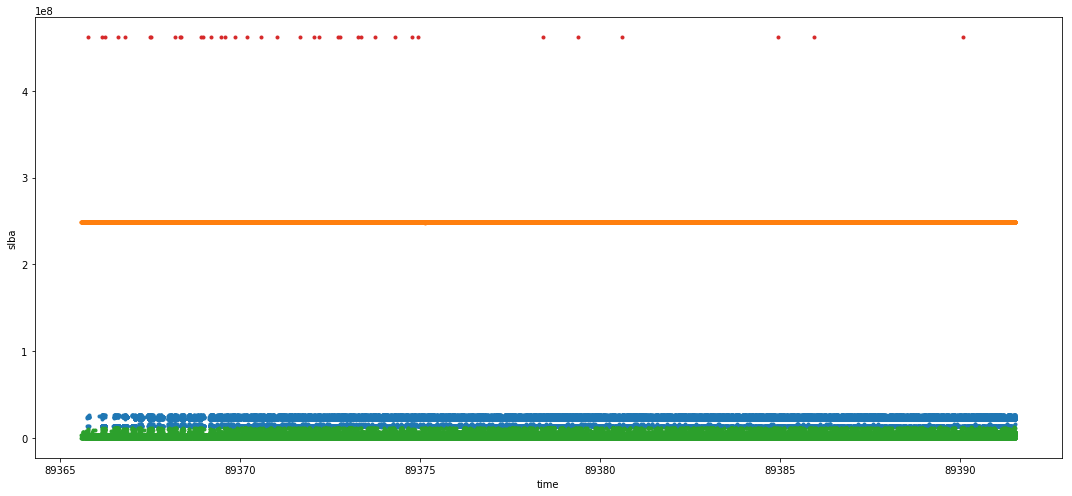

In [70]:
fig = plt.figure(figsize=(15, 7))

for i in range(k):
    plt.plot(datas[labels==i]['slba'], '.')

plt.ylabel('slba')
plt.xlabel('time')
fig.tight_layout()
plt.show()